# Clock Model: Temperature Sweep and Discrete Symmetry Breaking

The $q$-state clock model restricts the planar spin of the XY model to $q$ equally spaced angles $\theta_i = 2\pi k_i/q$ with $k_i \in \{0, \dots, q-1\}$, and keeps the XY coupling $H = -J \sum_{\langle i,j \rangle} \cos(\theta_i - \theta_j)$. This notebook uses the discrete implementation `DiscreteClockSimulation`, which stores the integer state $k_i$ of each site, with $q = 6$. The ground state has all spins in one of the $q$ directions and energy $e_0 = -2J$ per site. For $q = 2$ the model is the Ising model, for $q = 3$ it is the three-state Potts model, and for $q = 4$ it decouples into two Ising models. For $q \ge 5$ there are two transitions and an intermediate phase. Below $T_1$ the spins order along one of the $q$ directions and the discrete $Z_q$ symmetry is broken. Between $T_1$ and $T_2$ the discreteness is irrelevant and the system behaves like the quasi-ordered phase of the XY model, with algebraically decaying correlations. Above $T_2$ vortices unbind and the correlations decay exponentially [[1]](#Bibliography) [[2]](#Bibliography) [[5]](#Bibliography).

For $q = 6$, Tomita and Okabe locate the transitions at $T_1 = 0.7014(11)$ and $T_2 = 0.9008(6)$, with $\eta(T_1) = 0.113(3)$, close to the predicted $4/q^2 = 1/9$, and $\eta(T_2) = 0.243(5)$, close to $1/4$ [[5]](#Bibliography). They treat both transitions as of BKT type, as do Baek and Minnhagen for the upper one [[2]](#Bibliography), while Lapilli, Pfeifer, and Wexler argued that for $q = 6$ neither transition is of BKT type [[1]](#Bibliography). The constant `T1_CLOCK6 = 0.68` in the code, below which the sweep accepts a stranded random start and measures the ordered start, is the older estimate of Challa and Landau, who reported $T_1 = 0.68(2)$ and $T_2 = 0.92(1)$ [[6]](#Bibliography).

This notebook presents a thermodynamic temperature sweep that records magnetization, energy, susceptibility, specific heat, entropy, and integrated autocorrelation time across the three regimes. Because the model has exactly $q$ states per site, its entropy tends to $\ln q$ per site as $T \to \infty$. The sweep, however, integrates the specific heat from the highest sampled temperature and reports $S(T) - S(T_{\max})$. The stored outputs come from the inline fallback (one seed, $L = 32$), so the numbers quoted below describe that run.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from models.clock_model import DiscreteClockSimulation
from utils.equilibration import (
    _detect_quasi_steady_stuck,
    estimate_relaxation_time_two_start,
    ordered_start_seed,
    prepare_equilibrated_simulation,
)
from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.statistics import (
    DEFAULT_CONFIDENCE_LEVEL,
    calculate_autocorr,
    summarize_entropy_observable,
)
from utils.sweep_helpers import ThermoPoint, simulate_thermo_point

Q_DEFAULT = 6
# Approximate lower BKT temperature of the discrete q=6 clock model, below
# which the spins lock into one of the six directions.
T1_CLOCK6 = 0.68
S_REF = np.log(Q_DEFAULT)
# Data paths are relative to notebooks/, the directory the notebook runs from.
CACHE_PATH = Path('../results/clock/temperature_sweep_data.npz')
PALETTE = {
    'mag': '#4878CF',
    'eng': '#6ACC65',
    'chi': '#EE854A',
    'cv': '#D65F5F',
    'entropy': '#956CB4',
    'tau': '#8C613C',
}

plt.rcParams['figure.dpi'] = 120

print(f'Clock states q = {Q_DEFAULT}')
print(f'High-T entropy reference S_ref = ln({Q_DEFAULT}) = {S_REF:.4f}')
print(f'Primary sweep path: {CACHE_PATH}')

Clock states q = 6
High-T entropy reference S_ref = ln(6) = 1.7918
Primary sweep path: ../results/clock/temperature_sweep_data.npz


## Ordered and Disordered Configurations

The snapshots below show the local angle $\theta_i$ on a cyclic colour scale after equilibration with checkerboard Metropolis updates on a $48 \times 48$ lattice. With $q = 6$ only six colours can occur, and neighbouring colours on the scale belong to clock states that differ by $60^\circ$. At $T = 0.3$, deep in the ordered phase, one state covers the whole lattice apart from a handful of isolated sites in an adjacent state. At $T = 0.70$, which coincides with $T_1$ within its error bar, one state still dominates, but compact domains of the two adjacent states ($\pm 60^\circ$) cover a sizeable fraction of the lattice and the remaining three states are rare. At $T = 1.2$, above $T_2$, all six states appear in small domains a few lattice spacings across.

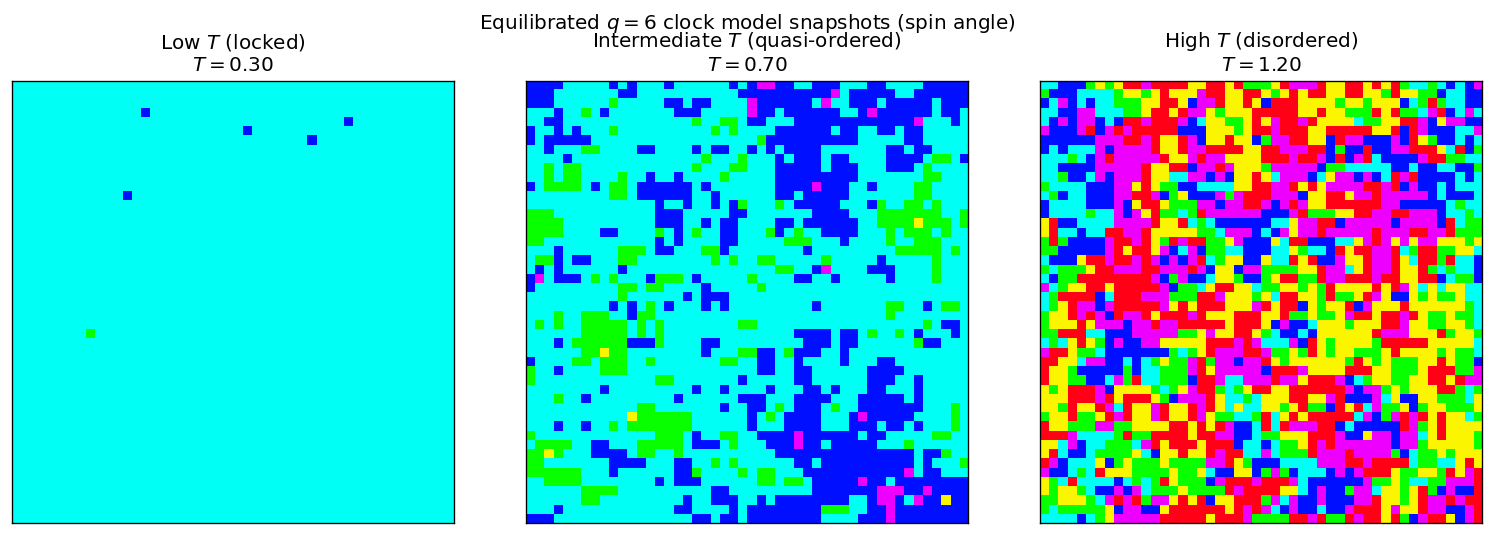

In [2]:
def _equilibrated_state(*, temp: float, size: int = 48, seed: int = 0) -> np.ndarray:
    sim, _ = prepare_equilibrated_simulation(
        model_cls=DiscreteClockSimulation, model_kwargs={'q': Q_DEFAULT}, size=size, temp=temp,
        seed=seed, chunk_size=120, max_steps=6000, detect_stuck=temp < T1_CLOCK6,
    )
    sim.run(n_steps=200)
    return np.array(sim.get_spin_field(), copy=True)

snapshot_temperatures = [0.3, 0.7, 1.2]
snapshot_titles = ['Low $T$ (locked)', 'Intermediate $T$ (quasi-ordered)', 'High $T$ (disordered)']
snapshot_states = [
    _equilibrated_state(temp=float(temp), seed=300 + idx)
    for idx, temp in enumerate(snapshot_temperatures)
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, spins, title, temp in zip(axes, snapshot_states, snapshot_titles, snapshot_temperatures, strict=True):
    angles = np.arctan2(spins[:, :, 1], spins[:, :, 0])
    ax.imshow(angles, cmap='hsv', vmin=-np.pi, vmax=np.pi, interpolation='nearest')
    ax.set_title(f'{title}\n$T = {temp:.2f}$')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Equilibrated $q = {Q_DEFAULT}$ clock model snapshots (spin angle)', y=0.98)
fig.tight_layout()
plt.show()

## Load or Compute Sweep Data

The notebook first checks for precomputed data at `../results/clock/temperature_sweep_data.npz` (relative to the `notebooks/` directory; produced by `scripts/clock/temperature_sweep.py`). If the cache contains at least ten temperature points with all required uncertainty fields, plots are built directly from those arrays. Otherwise a lightweight fallback sweep runs inline through `simulate_thermo_point`, the worker used by the production sweep. A random-start and an ordered-start simulation with independent seeds evolve until their smoothed magnetization traces satisfy the two-start cross-band criterion. Below `T1_CLOCK6 = 0.68` the ordered phase behaves like the Ising model: a random start can be stranded in a domain configuration whose $|M|$ stays on a plateau. There, quasi-steady stuck detection is enabled, and an accepted stuck state is measured on the ordered start. At higher temperatures both starts must converge, and a point that does not converge within 12 000 sweeps is stored as NaN. The stored fallback uses $L = 32$, 21 temperatures between 0.1 and 1.6, 3000 measurement sweeps, and one seed. The results are noisy, but they show the qualitative shape of each observable across the two transitions.

In [3]:
REQUIRED_KEYS = {
    'temperatures',
    'avg_m_value', 'avg_m_ci_low', 'avg_m_ci_high', 'avg_m_n_eff',
    'avg_e_value', 'avg_e_ci_low', 'avg_e_ci_high',
    'susc_value', 'susc_ci_low', 'susc_ci_high',
    'spec_h_value', 'spec_h_err', 'spec_h_ci_low', 'spec_h_ci_high',
    'tau_int',
    'undefined_autocorr_flag', 'tau_interval_unstable_flag',
}

fallback_meas_steps = 3_000
fallback_size = 32


def _run_local_sweep_point(
    *,
    temp: float,
    size: int,
    meas_steps: int,
    eq_probe_steps: int,
    eq_max_steps: int,
    seed: int,
) -> dict[str, float]:
    # The production sweep worker: two-start equilibration with independent
    # seeds, measurement on the start the equilibration certified, and the
    # standard blocking summaries.
    # Below T1 the discrete clock model orders like Ising, and a stranded
    # random start is replaced by the ordered start, as in the production sweep.
    allow_stuck = temp < T1_CLOCK6
    result = simulate_thermo_point(ThermoPoint(
        temperature=temp, size=size, meas_steps=meas_steps,
        eq_probe_steps=eq_probe_steps, eq_max_steps=eq_max_steps,
        eq_qs_sigma_threshold=0.05, eq_qs_min_steps=1500,
        qs_allow_stuck=allow_stuck, prefer_ordered_start=allow_stuck,
        temperature_index=0, seed_index=0, seed=seed,
        model_cls=DiscreteClockSimulation, model_kwargs={'q': Q_DEFAULT},
        confidence=DEFAULT_CONFIDENCE_LEVEL, derived_method='blocking', bootstrap_resamples=0,
    ))
    if result['equilibrated_flag'] == 0.0:
        # Not equilibrated within the step cap: report NaN rather than a biased value.
        result = {f'{obs}_{field}': float('nan')
                  for obs in ('avg_m', 'avg_e', 'susc', 'spec_h')
                  for field in ('value', 'err', 'tau_int', 'n_eff')}
    z = float(norm.ppf(0.5 + DEFAULT_CONFIDENCE_LEVEL / 2.0))
    point: dict[str, float] = {}
    for obs in ('avg_m', 'avg_e', 'susc', 'spec_h'):
        value, err = float(result[f'{obs}_value']), float(result[f'{obs}_err'])
        point[f'{obs}_value'] = value
        point[f'{obs}_ci_low'] = value - z * err
        point[f'{obs}_ci_high'] = value + z * err
    point['avg_m_n_eff'] = float(result['avg_m_n_eff'])
    point['spec_h_err'] = float(result['spec_h_err'])
    point['tau_int'] = float(result['avg_m_tau_int'])
    # A single run gives no interval for tau_int itself; the band collapses
    # onto the point estimate instead of borrowing the error of |M|.
    point['tau_int_ci_low'] = point['tau_int']
    point['tau_int_ci_high'] = point['tau_int']
    return point



cache_loaded = False
cache_reason = ''
requested_n_seeds = 1
retained_n_seeds = 1

if CACHE_PATH.exists():
    cache = np.load(CACHE_PATH)
    if REQUIRED_KEYS.issubset(set(cache.files)) and int(cache['temperatures'].size) >= 10:
        temperatures = np.asarray(cache['temperatures'], dtype=float)
        avg_m = np.asarray(cache['avg_m_value'], dtype=float)
        avg_m_ci_low = np.asarray(cache['avg_m_ci_low'], dtype=float)
        avg_m_ci_high = np.asarray(cache['avg_m_ci_high'], dtype=float)
        avg_m_n_eff = np.asarray(cache['avg_m_n_eff'], dtype=float)
        avg_e = np.asarray(cache['avg_e_value'], dtype=float)
        avg_e_ci_low = np.asarray(cache['avg_e_ci_low'], dtype=float)
        avg_e_ci_high = np.asarray(cache['avg_e_ci_high'], dtype=float)
        susc = np.asarray(cache['susc_value'], dtype=float)
        susc_ci_low = np.asarray(cache['susc_ci_low'], dtype=float)
        susc_ci_high = np.asarray(cache['susc_ci_high'], dtype=float)
        spec_h = np.asarray(cache['spec_h_value'], dtype=float)
        spec_h_err = np.asarray(cache['spec_h_err'], dtype=float)
        spec_h_ci_low = np.asarray(cache['spec_h_ci_low'], dtype=float)
        spec_h_ci_high = np.asarray(cache['spec_h_ci_high'], dtype=float)
        tau_int = np.asarray(cache['tau_int'], dtype=float)
        tau_int_ci_low = (
            np.asarray(cache['tau_int_ci_low'], dtype=float)
            if 'tau_int_ci_low' in cache.files
            else tau_int
        )
        tau_int_ci_high = (
            np.asarray(cache['tau_int_ci_high'], dtype=float)
            if 'tau_int_ci_high' in cache.files
            else tau_int
        )
        undefined_autocorr_flag = np.asarray(cache['undefined_autocorr_flag'], dtype=np.uint8)
        tau_interval_unstable_flag = np.asarray(cache['tau_interval_unstable_flag'], dtype=np.uint8)
        low_effective_sample_flag = (
            np.asarray(cache['low_effective_sample_flag'], dtype=np.uint8)
            if 'low_effective_sample_flag' in cache.files
            else np.zeros_like(temperatures, dtype=np.uint8)
        )
        entropy = (
            np.asarray(cache['entropy_value'], dtype=float)
            if 'entropy_value' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_low = (
            np.asarray(cache['entropy_ci_low'], dtype=float)
            if 'entropy_ci_low' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_high = (
            np.asarray(cache['entropy_ci_high'], dtype=float)
            if 'entropy_ci_high' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        confidence_level = float(cache['confidence_level']) if 'confidence_level' in cache.files else DEFAULT_CONFIDENCE_LEVEL
        requested_n_seeds = int(cache['requested_n_seeds']) if 'requested_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        retained_n_seeds = int(cache['retained_n_seeds']) if 'retained_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        n_seeds = retained_n_seeds
        data_source = (
            f'Loaded cached sweep from {CACHE_PATH} '
            f"at L={int(cache['size']) if 'size' in cache.files else 'unknown'}, "
            f"{int(cache['meas_steps']) if 'meas_steps' in cache.files else 'unknown'} "
            f'measurement steps, using {retained_n_seeds} retained seeds '
            f'out of {requested_n_seeds} requested.'
        )
        cache_loaded = True
    else:
        n_cached = int(cache['temperatures'].size) if 'temperatures' in cache.files else 0
        cache_reason = f'cache exists but only provides {n_cached} temperature points'
else:
    cache_reason = 'cache file not found'

if not cache_loaded:
    temperatures = np.linspace(0.1, 1.6, 21)
    avg_m = np.empty_like(temperatures)
    avg_m_ci_low = np.empty_like(temperatures)
    avg_m_ci_high = np.empty_like(temperatures)
    avg_m_n_eff = np.empty_like(temperatures)
    avg_e = np.empty_like(temperatures)
    avg_e_ci_low = np.empty_like(temperatures)
    avg_e_ci_high = np.empty_like(temperatures)
    susc = np.empty_like(temperatures)
    susc_ci_low = np.empty_like(temperatures)
    susc_ci_high = np.empty_like(temperatures)
    spec_h = np.empty_like(temperatures)
    spec_h_err = np.empty_like(temperatures)
    spec_h_ci_low = np.empty_like(temperatures)
    spec_h_ci_high = np.empty_like(temperatures)
    tau_int = np.empty_like(temperatures)
    tau_int_ci_low = np.empty_like(temperatures)
    tau_int_ci_high = np.empty_like(temperatures)
    spec_h_samples = np.empty((temperatures.size, 1), dtype=float)

    for idx, temp in enumerate(temperatures):
        point = _run_local_sweep_point(
            temp=float(temp),
            size=fallback_size,
            meas_steps=fallback_meas_steps,
            eq_probe_steps=150,
            eq_max_steps=12_000,
            seed=2_000 + idx,
        )
        avg_m[idx] = point['avg_m_value']
        avg_m_ci_low[idx] = point['avg_m_ci_low']
        avg_m_ci_high[idx] = point['avg_m_ci_high']
        avg_m_n_eff[idx] = point['avg_m_n_eff']
        avg_e[idx] = point['avg_e_value']
        avg_e_ci_low[idx] = point['avg_e_ci_low']
        avg_e_ci_high[idx] = point['avg_e_ci_high']
        susc[idx] = point['susc_value']
        susc_ci_low[idx] = point['susc_ci_low']
        susc_ci_high[idx] = point['susc_ci_high']
        spec_h[idx] = point['spec_h_value']
        spec_h_err[idx] = point['spec_h_err']
        spec_h_ci_low[idx] = point['spec_h_ci_low']
        spec_h_ci_high[idx] = point['spec_h_ci_high']
        tau_int[idx] = point['tau_int']
        tau_int_ci_low[idx] = point['tau_int_ci_low']
        tau_int_ci_high[idx] = point['tau_int_ci_high']
        spec_h_samples[idx, 0] = point['spec_h_value']

    entropy_bundle = summarize_entropy_observable(
        temperatures=temperatures,
        specific_heat_samples=spec_h_samples,
        specific_heat_err=spec_h_err,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
        method='blocking',
    )
    entropy = np.asarray(entropy_bundle['value'], dtype=float)
    entropy_ci_low = np.asarray(entropy_bundle['ci_low'], dtype=float)
    entropy_ci_high = np.asarray(entropy_bundle['ci_high'], dtype=float)
    undefined_autocorr_flag = (~np.isfinite(tau_int)).astype(np.uint8)
    rel_width = (tau_int_ci_high - tau_int_ci_low) / np.maximum(np.abs(tau_int), 1e-12)
    tau_interval_unstable_flag = np.asarray(
        np.isfinite(rel_width) & (rel_width > 1.0),
        dtype=np.uint8,
    )
    low_effective_sample_flag = np.asarray(
        np.isfinite(avg_m_n_eff) & (avg_m_n_eff < 20.0),
        dtype=np.uint8,
    )
    confidence_level = DEFAULT_CONFIDENCE_LEVEL
    n_seeds = 1
    requested_n_seeds = 1
    retained_n_seeds = 1
    data_source = (
        'Computed a lightweight checkerboard-Metropolis fallback sweep '
        f'at L={fallback_size}, {temperatures.size} temperature points, '
        f'{fallback_meas_steps} measurement steps, 1 seed (reduced for interactive runtime) '
        f'because {cache_reason}.'
    )

exclude_from_thermo_plots = undefined_autocorr_flag > 0

avg_m_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m)
avg_m_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_low)
avg_m_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_high)
avg_e_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e)
avg_e_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_low)
avg_e_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_high)
susc_plot = np.where(exclude_from_thermo_plots, np.nan, susc)
susc_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_low)
susc_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_high)
spec_h_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h)
spec_h_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_low)
spec_h_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_high)
entropy_plot = np.where(exclude_from_thermo_plots, np.nan, entropy)
entropy_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_low)
entropy_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_high)

print(data_source)
print(f'Temperature points: {temperatures.size}')
print(
    f'retained seeds = {retained_n_seeds} / requested seeds = {requested_n_seeds}, '
    f'confidence level = {confidence_level:.2f}'
)
print(f'Excluded points in thermodynamic plots: {int(np.sum(exclude_from_thermo_plots))}')

Computed a lightweight checkerboard-Metropolis fallback sweep at L=32, 21 temperature points, 3000 measurement steps, 1 seed (reduced for interactive runtime) because cache file not found.
Temperature points: 21
retained seeds = 1 / requested seeds = 1, confidence level = 0.68
Excluded points in thermodynamic plots: 1


## Convergence Diagnostics

The two-start protocol runs a random-start and an ordered-start simulation with independent seeds until their smoothed magnetization traces overlap. The three panels below show 1500 sweeps on a $32 \times 32$ lattice. At $T = 0.3$ the ordered start stays at $|M| \approx 1$, while the random start coarsens and then stops on a plateau at $|M| \approx 0.87$ after about 900 sweeps. The plateau is a frozen domain configuration, for example a stripe bounded by straight, system-spanning domain walls: such walls have no curvature to drive their removal, and local moves at this temperature cannot remove them on the time scale shown. The diagnostic marks the panel as a quasi-steady stuck state, which is the case where the sweep measures the ordered start. At $T = 0.7$ the random start needs about 700 sweeps to reach the ordered-start level near $|M| \approx 0.8$, and the cross-band criterion is met after about 870 sweeps. At $T = 1.2$ both traces fluctuate between $|M| \approx 0.05$ and $0.4$, and the criterion is met after about 320 sweeps.

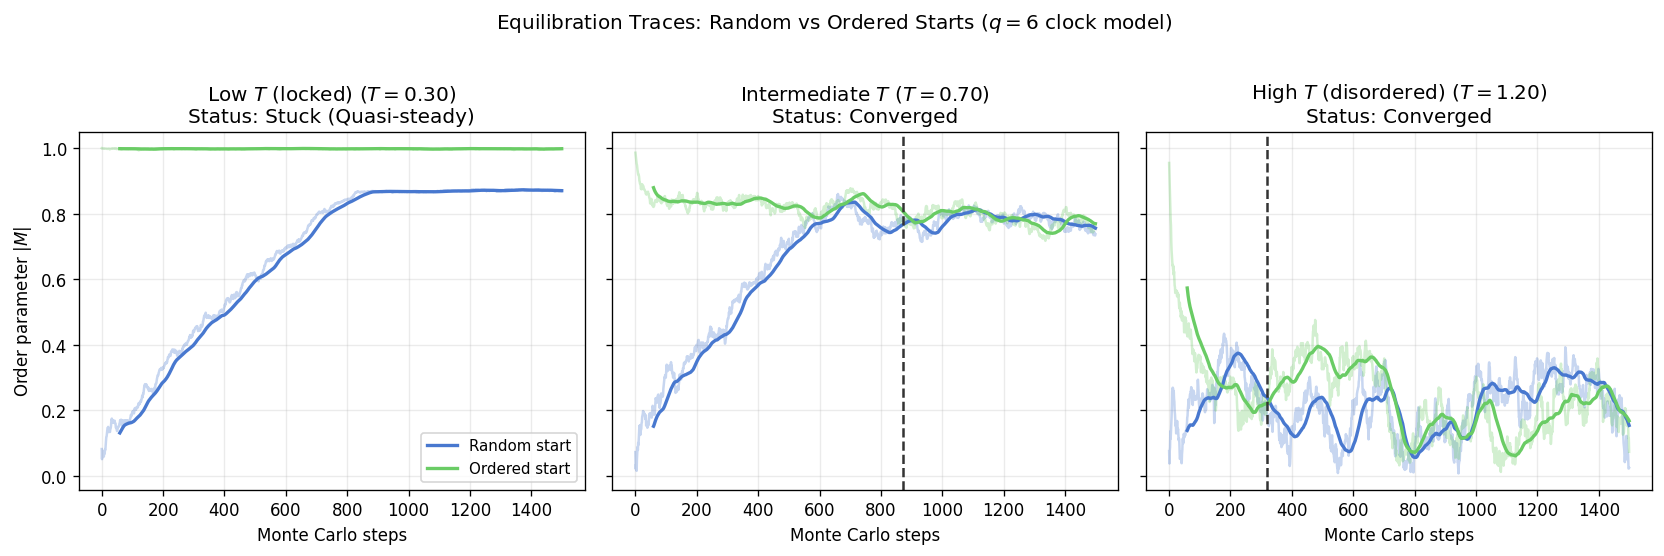

In [4]:
diagnostic_temps = [0.3, 0.7, 1.2]
diagnostic_titles = ['Low $T$ (locked)', 'Intermediate $T$', 'High $T$ (disordered)']
diagnostic_steps = 1500

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, t, title in zip(axes, diagnostic_temps, diagnostic_titles, strict=True):
    sim_r = DiscreteClockSimulation(size=32, temp=t, q=Q_DEFAULT, update='checkerboard', init_state='random', seed=42)
    sim_o = DiscreteClockSimulation(size=32, temp=t, q=Q_DEFAULT, update='checkerboard', init_state='ordered', seed=ordered_start_seed(seed=42))

    m_r_list, _ = sim_r.run(n_steps=diagnostic_steps)
    m_o_list, _ = sim_o.run(n_steps=diagnostic_steps)

    m_r = np.asarray(m_r_list, dtype=float)
    m_o = np.asarray(m_o_list, dtype=float)

    tau_est = estimate_relaxation_time_two_start(trace_random=m_r, trace_ordered=m_o, smooth_window=60, dwell_window=60)

    smooth_r = np.convolve(m_r, np.ones(60) / 60, mode='valid')
    smooth_o = np.convolve(m_o, np.ones(60) / 60, mode='valid')
    is_stuck = _detect_quasi_steady_stuck(trace_random=smooth_r, trace_ordered=smooth_o, lattice_size=32)

    ax.plot(m_r, color=PALETTE['mag'], alpha=0.3)
    ax.plot(m_o, color=PALETTE['eng'], alpha=0.3)
    ax.plot(np.arange(59, diagnostic_steps), smooth_r, color=PALETTE['mag'], lw=2, label='Random start')
    ax.plot(np.arange(59, diagnostic_steps), smooth_o, color=PALETTE['eng'], lw=2, label='Ordered start')

    status_text = 'Converged'
    if tau_est < diagnostic_steps:
        ax.axvline(tau_est, color='0.2', ls='--', lw=1.5, label='Convergence achieved')
    else:
        if t < 0.5 and is_stuck:
            status_text = 'Stuck (Quasi-steady)'
        else:
            status_text = 'Not converged'

    ax.set_title(f'{title} ($T = {t:.2f}$)\nStatus: {status_text}')
    ax.set_xlabel('Monte Carlo steps')
    if ax is axes[0]:
        ax.set_ylabel(r'Order parameter $|M|$')
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=9, loc='lower right')
fig.suptitle(f'Equilibration Traces: Random vs Ordered Starts ($q = {Q_DEFAULT}$ clock model)', y=1.02)
fig.tight_layout()
plt.show()

## Magnetization and Energy

In the fallback run $|M|$ equals 1 to within $10^{-2}$ up to $T \approx 0.4$, decreases to 0.94 at $T = 0.55$ and 0.80 at $T = 0.7$, and then falls more steeply to 0.53 at $T = 1.0$ and 0.26 at $T = 1.15$, reaching 0.07 at $T = 1.6$. The curve has no sharp feature at $T_1$. The decrease through the intermediate phase reflects the growth of spin-wave and domain fluctuations on a lattice of fixed size, and the steepest drop lies above $T_2$, at the finite-size crossover to disorder. The lowest temperature, $T = 0.1$, is missing from the plots: the $|M|$ trace stays exactly at 1 for all 3000 measurement sweeps (an excitation costs $2J$, a Boltzmann factor of $e^{-20}$ at this temperature), so its variance is zero, its autocorrelation is undefined, and the point is excluded rather than given a zero error.

The energy per site stays at the ground-state value $-2J$ up to $T \approx 0.3$ and then rises smoothly to $-0.72$ at $T = 1.6$. The flat start differs from the XY model, where $E \approx -2J + T/2$ at low temperature. In the discrete model the cheapest excitation, rotating one spin of an ordered region to an adjacent state, costs $4J(1 - \cos 60^\circ) = 2J$, so the thermal excitation density is suppressed as $e^{-2J/T}$.

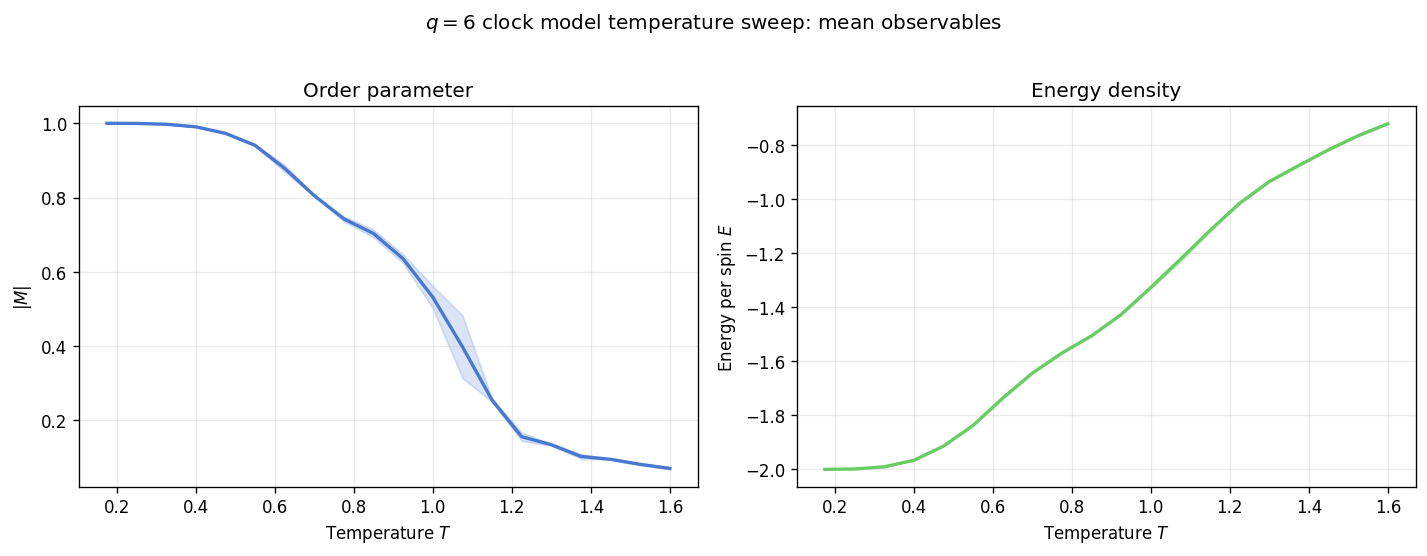

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, avg_m_plot, color=PALETTE['mag'], lw=2)
axes[0].fill_between(temperatures, avg_m_ci_low_plot, avg_m_ci_high_plot, color=PALETTE['mag'], alpha=0.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'$|M|$')
axes[0].set_title('Order parameter')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, avg_e_plot, color=PALETTE['eng'], lw=2)
axes[1].fill_between(temperatures, avg_e_ci_low_plot, avg_e_ci_high_plot, color=PALETTE['eng'], alpha=0.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Energy per spin $E$')
axes[1].set_title('Energy density')
axes[1].grid(alpha=0.25)

fig.suptitle(f'$q = {Q_DEFAULT}$ clock model temperature sweep: mean observables', y=1.02)
fig.tight_layout()
plt.show()

## Susceptibility and Specific Heat

The susceptibility $\chi = N\,\mathrm{Var}(|M|)/T$ is close to zero in the ordered phase, stays near 1 to 1.5 between $T = 0.7$ and $0.85$, and rises to a single peak of about 15 at $T \approx 1.08$, above $T_2 = 0.90$. As in the XY sweep, the estimator subtracts $\langle |M| \rangle^2$, so it peaks where the finite lattice loses its order rather than at the bulk transition, and the shift of a BKT-type transition decays only logarithmically with $L$ [[5]](#Bibliography).

The specific heat stays below 0.05 up to $T = 0.25$, the activated behaviour described above, and then rises steeply. It shows a broad shoulder of about 1.1 between $T = 0.55$ and $0.63$, below $T_1$, and a maximum of about 1.5 at $T \approx 1.08$ to $1.15$, above $T_2$. Neither feature marks a transition temperature. At a BKT-type transition the free energy has only an essential singularity, and the specific heat maxima of clock models lie away from $T_1$ and $T_2$ [[1]](#Bibliography). The two-hump shape is suggestive of the two energy scales of the model, the cost of domain walls between clock states at low temperature and the unbinding of vortices at high temperature. A single seed at $L = 32$ cannot establish it.

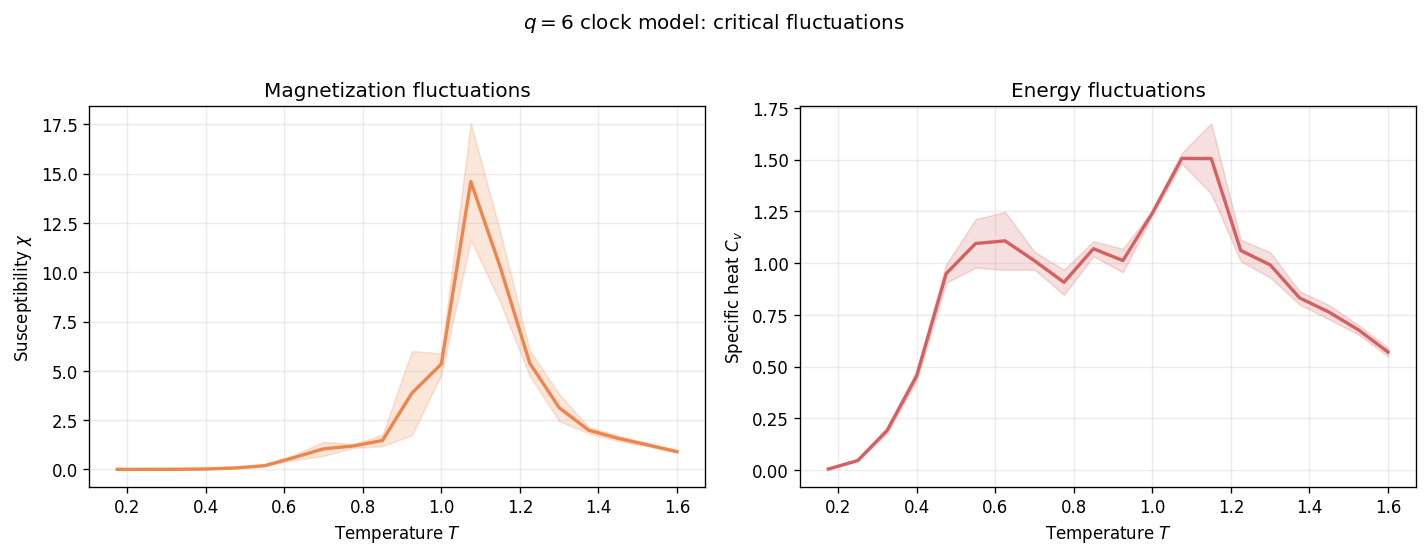

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, susc_plot, color=PALETTE['chi'], lw=2)
axes[0].fill_between(temperatures, susc_ci_low_plot, susc_ci_high_plot, color=PALETTE['chi'], alpha=0.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Susceptibility $\chi$')
axes[0].set_title('Magnetization fluctuations')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, spec_h_plot, color=PALETTE['cv'], lw=2)
axes[1].fill_between(temperatures, spec_h_ci_low_plot, spec_h_ci_high_plot, color=PALETTE['cv'], alpha=0.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Specific heat $C_v$')
axes[1].set_title('Energy fluctuations')
axes[1].grid(alpha=0.25)

fig.suptitle(f'$q = {Q_DEFAULT}$ clock model: critical fluctuations', y=1.02)
fig.tight_layout()
plt.show()

## Entropy

The relative entropy $S(T) - S(T_{\max})$ is reconstructed by thermodynamic integration of $C_v(T)/T$ from the highest sampled temperature, $T_{\max} = 1.6$, downward. Its zero is therefore at $T_{\max}$, and the dotted line at $\ln 6 \approx 1.79$ marks the infinite-temperature entropy of the discrete six-state model only as a scale. In the fallback run the curve is flat at about $-1.50$ below $T \approx 0.33$, where the activated specific heat vanishes, and rises through both transition regions to zero at $T_{\max}$. The ordered state has a ground-state entropy of $(\ln 6)/N$ per site, which is negligible, so the integrated rise of 1.50 is an estimate of $S(T_{\max})$ itself. It amounts to about 84% of $\ln 6$. The remaining 0.29 per site is released above $T = 1.6$, as the short-range correlations of the disordered phase decay.

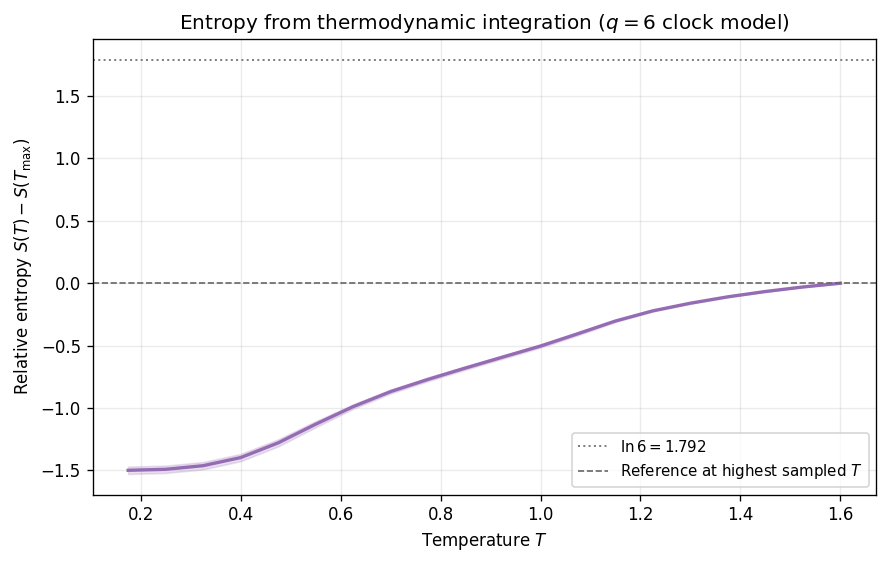

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(temperatures, entropy_plot, color=PALETTE['entropy'], lw=2)
ax.fill_between(temperatures, entropy_ci_low_plot, entropy_ci_high_plot, color=PALETTE['entropy'], alpha=0.2)
ax.axhline(S_REF, color='0.5', ls=':', lw=1.2, label=rf'$\ln {Q_DEFAULT} = {S_REF:.3f}$')
ax.axhline(0.0, color='0.4', ls='--', lw=1.0, label=r'Reference at highest sampled $T$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'Relative entropy $S(T) - S(T_{\max})$')
ax.set_title(f'Entropy from thermodynamic integration ($q = {Q_DEFAULT}$ clock model)')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Critical Slowing Down

The integrated autocorrelation time $\tau_{\mathrm{int}}$ of $|M|$ is below about 20 sweeps in the ordered phase ($T \le 0.55$) and above $T \approx 1.4$. Between these limits it rises to between about 30 and 150 sweeps, with the largest values at $T \approx 0.78$ (about 150) and $T \approx 1.08$ (about 145). The first lies in the intermediate phase, where correlations decay algebraically and local updates are slow at every temperature, much as in the low-temperature phase of the XY model. The second coincides with the $\chi$ and $C_v$ maxima at the finite-size crossover to disorder. The values in between scatter strongly from point to point, which is the expected noise of a single 3000-sweep series per temperature. With $N_{\mathrm{eff}} = N_{\mathrm{meas}} / (2\tau_{\mathrm{int}})$, the effective sample size drops from about 180 to 340 for $T \le 0.4$ to about 10 to 15 at four points ($T = 0.78$, $0.85$, $1.0$, $1.08$), which carry the low-$N_{\mathrm{eff}}$ cross marker. The "flagged point" entry in the left legend refers to $T = 0.1$, where $\tau_{\mathrm{int}}$ is undefined and no marker can be drawn [[3]](#Bibliography) [[4]](#Bibliography).

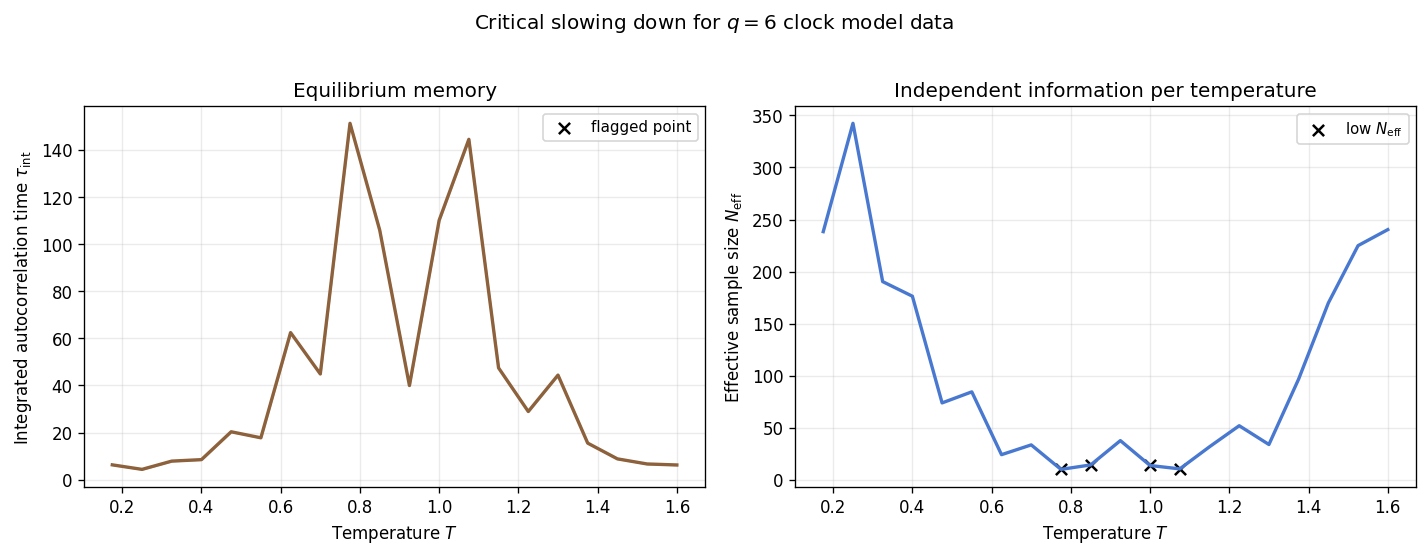

In [8]:
flagged_tau = (undefined_autocorr_flag > 0) | (tau_interval_unstable_flag > 0)
flagged_neff = low_effective_sample_flag > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, tau_int, color=PALETTE['tau'], lw=2)
axes[0].fill_between(temperatures, tau_int_ci_low, tau_int_ci_high, color=PALETTE['tau'], alpha=0.2)
if np.any(flagged_tau):
    axes[0].scatter(
        temperatures[flagged_tau],
        tau_int[flagged_tau],
        color='black',
        marker='x',
        s=45,
        label='flagged point',
    )
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Integrated autocorrelation time $\tau_{\mathrm{int}}$')
axes[0].set_title('Equilibrium memory')
axes[0].grid(alpha=0.25)
if np.any(flagged_tau):
    axes[0].legend(fontsize=9)

axes[1].plot(temperatures, avg_m_n_eff, color=PALETTE['mag'], lw=2)
if np.any(flagged_neff):
    axes[1].scatter(
        temperatures[flagged_neff],
        avg_m_n_eff[flagged_neff],
        color='black',
        marker='x',
        s=45,
        label=r'low $N_{\mathrm{eff}}$',
    )
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Effective sample size $N_{\mathrm{eff}}$')
axes[1].set_title('Independent information per temperature')
axes[1].grid(alpha=0.25)
if np.any(flagged_neff):
    axes[1].legend(fontsize=9)

fig.suptitle(f'Critical slowing down for $q = {Q_DEFAULT}$ clock model data', y=1.02)
fig.tight_layout()
plt.show()

## Autocorrelation Function at Three Temperatures

The autocorrelation function $\rho_M(\tau)$ shows how the Markov chain decorrelates its magnetization at the three snapshot temperatures, using 1600-sweep trajectories on a $40 \times 40$ lattice. The integrated time is summed up to the self-consistent Madras-Sokal window chosen by `calculate_autocorr`, and only the first 160 lags are plotted. In the ordered phase at $T = 0.3$ the deviations of $|M|$ from 1 are isolated thermal excitations that heal within a few sweeps, so $\rho_M$ reaches zero near lag 20 and $\tau_{\mathrm{int}} \approx 5.6$. At $T = 0.7$, at the lower transition, and at $T = 1.2$, in the disordered phase near the crossover, the decay is slow: $\tau_{\mathrm{int}} \approx 58$ and $42$ sweeps. At $T = 0.7$ the correlation is still about 0.13 at lag 160, so the estimate from this short series is uncertain [[3]](#Bibliography) [[4]](#Bibliography).

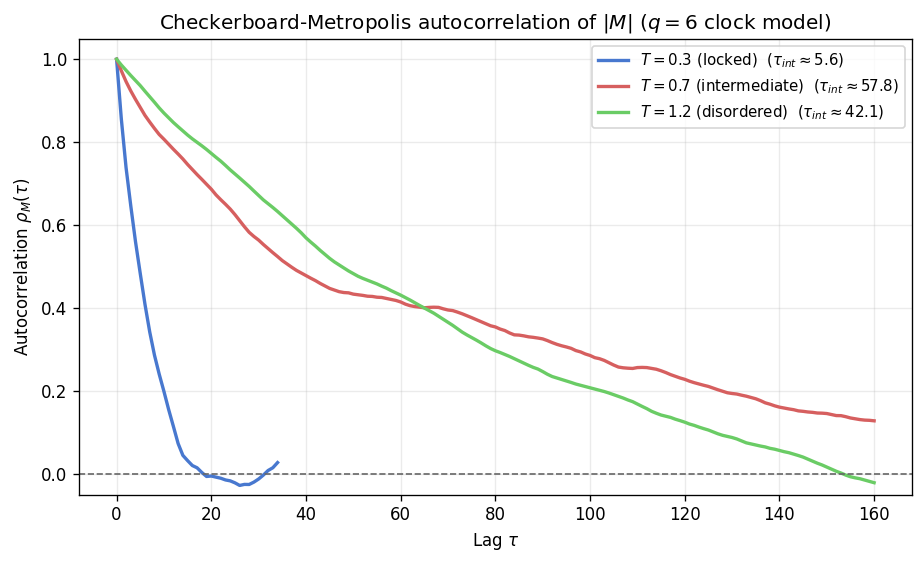

In [9]:
autocorr_temperatures = [0.3, 0.7, 1.2]
autocorr_labels = ['$T = 0.3$ (locked)', '$T = 0.7$ (intermediate)', '$T = 1.2$ (disordered)']
autocorr_colors = ['#4878CF', '#D65F5F', '#6ACC65']

fig, ax = plt.subplots(figsize=(7.8, 4.8))

for idx, (temp, label, color) in enumerate(zip(autocorr_temperatures, autocorr_labels, autocorr_colors, strict=True)):
    sim, _ = prepare_equilibrated_simulation(
        model_cls=DiscreteClockSimulation, model_kwargs={'q': Q_DEFAULT}, size=40, temp=float(temp),
        seed=6_000 + idx, chunk_size=120, max_steps=9_000, detect_stuck=temp < T1_CLOCK6,
    )
    mags, _ = sim.run(n_steps=1_600)
    mags_arr = np.asarray(mags, dtype=float)
    try:
        # No lag cap: the Madras-Sokal window sets the summation range, so tau_int
        # is not truncated when rho(t) is still large at the plotted lags.
        corr, tau_here = calculate_autocorr(time_series=mags_arr)
    except ZeroVarianceAutocorrelationError:
        corr = np.array([np.nan])
        tau_here = float('nan')
    # Plot only the first 160 lags so the fast-decaying curves stay readable.
    corr_plot = corr[:161]
    lags = np.arange(corr_plot.size)
    ax.plot(lags, corr_plot, lw=2, color=color, label=f'{label}  ($\\tau_{{int}} \\approx {tau_here:.1f}$)')

ax.axhline(0.0, color='0.4', ls='--', lw=1.0)
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'Autocorrelation $\rho_M(\tau)$')
ax.set_title(rf'Checkerboard-Metropolis autocorrelation of $|M|$ ($q = {Q_DEFAULT}$ clock model)')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Synthesis

The fallback sweep shows the three regimes of the $q = 6$ clock model. Below $T_1$ the lattice is ordered along one clock direction, $|M|$ is close to 1, the energy sits at $-2J$, and the specific heat is activated across the $2J$ gap. In the intermediate phase the magnetization decreases without vanishing on this lattice, and the autocorrelation time is large, as expected for a phase with algebraic correlations. Above $T_2$ the system disorders, and the susceptibility and specific heat maxima together with a second autocorrelation peak sit near $T \approx 1.1$, shifted above $T_2$ by finite size. A single seed at $L = 32$ resolves neither transition temperature. Comparing these curves with the XY Temperature Sweep notebook shows what discreteness adds: a gapped, truly ordered low-temperature phase that has no counterpart in the continuous-symmetry model.

## Bibliography

[[1]](#Bibliography) C. M. Lapilli, P. Pfeifer, and C. Wexler, "Universality away from critical points in two-dimensional phase transitions," *Physical Review Letters* 96, 140603 (2006). [arXiv:cond-mat/0511559](https://arxiv.org/abs/cond-mat/0511559)

[[2]](#Bibliography) S. K. Baek and P. Minnhagen, "Non-Kosterlitz-Thouless transitions for the q-state clock models," *Physical Review E* 82, 031102 (2010). [arXiv:1009.0356](https://arxiv.org/abs/1009.0356) [APS](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.82.031102)

[[3]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), reprinted in *Functional Integration: Basics and Applications* (1997). [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, *Monte Carlo Methods in Statistical Physics*, Oxford University Press (1999). Textbook; no open-access edition. For an open introduction to the same methods, see H. G. Katzgraber, "Introduction to Monte Carlo Methods," lecture notes (2009). [arXiv:0905.1629](https://arxiv.org/abs/0905.1629)

[[5]](#Bibliography) Y. Tomita and Y. Okabe, "Probability-changing cluster algorithm for two-dimensional XY and clock models" (2002). Transition temperatures and $\eta$ exponents of the $q = 6, 8, 12$ clock models. [arXiv:cond-mat/0202161](https://arxiv.org/abs/cond-mat/0202161)

[[6]](#Bibliography) M. S. S. Challa and D. P. Landau, "Critical behavior of the six-state clock model in two dimensions," *Physical Review B* 33, 437 (1986).